# TP2 — Analyse Factorielle des Correspondances (AFC)

**Cours :** Analyse Numérique & Statistique — GL3  
**Enseignant :** Pr. Adnène Arbi — INSAT  
**Étudiants :** Rayen Lagleg & Wissem Mekki  

---

## Objectif
L'AFC est une méthode d'analyse exploratoire multivariée qui permet d'étudier les associations entre les **lignes** et les **colonnes** d'un tableau de contingence. Elle projette lignes et colonnes dans un espace factoriel de faible dimension, en maximisant l'inertie expliquée.

**Données :** Tableau de contingence 10×8 croisant 10 catégories socio-professionnelles avec 8 types d'hébergement en vacances.

---
## Étape 0 — Imports et configuration

On importe uniquement **NumPy**, **Pandas** et **Matplotlib**. Toutes les étapes de l'AFC seront codées à la main (pas de `sklearn`, pas de `prince`) pour que chaque calcul soit transparent et pédagogique.

In [3]:
import numpy as np                        # calcul matriciel
import pandas as pd                       # affichage tabulaire
import matplotlib.pyplot as plt           # graphiques
import matplotlib.ticker as mticker       # formatage des axes

# Paramètres d'affichage : 4 décimales, largeur maximale des colonnes
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
np.set_printoptions(precision=4, suppress=True)

# Couleurs réutilisées dans les graphiques
COLOR_ROWS = '#1f77b4'   # bleu pour les lignes (catégories socio-pro)
COLOR_COLS = '#d62728'   # rouge pour les colonnes (types d'hébergement)

---
## Étape 1 — Chargement et affichage du tableau de contingence brut

Le tableau de contingence $\mathbf{N}$ est une matrice $r \times c$ (ici $10 \times 8$) dont l'élément $n_{ij}$ est l'effectif observé dans la cellule $(i, j)$.

$$\mathbf{N} = \bigl[n_{ij}\bigr]_{i=1\ldots r,\; j=1\ldots c}$$

In [4]:
# -----------------------------------------------------------------------
# Noms des modalités lignes (catégories socio-professionnelles)
# -----------------------------------------------------------------------
noms_lignes = [
    'Agriculteur', 'Salariés', 'Patrons', 'Cadre sup',
    'Cadre moy',   'Employés', 'Ouvriers', 'Personnels',
    'Autres actif','Non actifs'
]

# -----------------------------------------------------------------------
# Noms des modalités colonnes (types d'hébergement en vacances)
# -----------------------------------------------------------------------
noms_colonnes = ['hotel', 'locat', 'propri', 'parent',
                 'amis',  'tente', 'villag', 'divers']

# -----------------------------------------------------------------------
# Tableau de contingence brut (effectifs observés)
# Chaque ligne correspond à une catégorie socio-professionnelle
# -----------------------------------------------------------------------
N_data = np.array([
    [ 160,   28,   0,  321,  36,  141,  45,  65],   # Agriculteur
    [  35,   34,   1,  178,   8,    0,   4,   0],   # Salariés
    [ 700,  354, 229,  959, 185,  292, 119, 140],   # Patrons
    [ 961,  471, 633, 1580, 305,  360, 162, 148],   # Cadre sup
    [ 572,  537, 279, 1689, 206,  748, 155, 112],   # Cadre moy
    [ 441,  404, 166, 1079, 178,  434, 178,  92],   # Employés
    [ 783, 1114, 387, 4052, 497, 1464, 525, 387],   # Ouvriers
    [  65,   43,  21,  294,  79,   57,  18,   6],   # Personnels
    [  77,   60, 189,  839,  53,  124,  28,  53],   # Autres actif
    [ 741,  332, 327, 1789, 311,  236, 102, 102],   # Non actifs
], dtype=float)   # dtype float pour éviter les divisions entières

# -----------------------------------------------------------------------
# Effectif total N = somme de tous les éléments du tableau
# -----------------------------------------------------------------------
N_total = N_data.sum()
print(f"Effectif total N = {N_total:.0f}")
print(f"Dimensions du tableau : {N_data.shape[0]} lignes × {N_data.shape[1]} colonnes\n")

# Encapsulation dans un DataFrame Pandas pour un affichage lisible
df_N = pd.DataFrame(N_data, index=noms_lignes, columns=noms_colonnes)

# Ajout des totaux marginaux pour faciliter la lecture
df_N['TOTAL'] = df_N.sum(axis=1)              # total ligne
df_N.loc['TOTAL'] = df_N.sum(axis=0)          # total colonne

print("Tableau de contingence brut (effectifs n_ij) :")
df_N

Effectif total N = 31079
Dimensions du tableau : 10 lignes × 8 colonnes

Tableau de contingence brut (effectifs n_ij) :


,hotel,locat,propri,parent,amis,tente,villag,divers,TOTAL
Agriculteur,160.0000,28.0000,0.0000,321.0000,36.0000,141.0000,45.0000,65.0000,796.0000
Salariés,35.0000,34.0000,1.0000,178.0000,8.0000,0.0000,4.0000,0.0000,260.0000
Patrons,700.0000,354.0000,229.0000,959.0000,185.0000,292.0000,119.0000,140.0000,2978.0000
Cadre sup,961.0000,471.0000,633.0000,1580.0000,305.0000,360.0000,162.0000,148.0000,4620.0000
Cadre moy,572.0000,537.0000,279.0000,1689.0000,206.0000,748.0000,155.0000,112.0000,4298.0000
Employés,441.0000,404.0000,166.0000,1079.0000,178.0000,434.0000,178.0000,92.0000,2972.0000
Ouvriers,783.0000,1114.0000,387.0000,4052.0000,497.0000,1464.0000,525.0000,387.0000,9209.0000
Personnels,65.0000,43.0000,21.0000,294.0000,79.0000,57.0000,18.0000,6.0000,583.0000
Autres actif,77.0000,60.0000,189.0000,839.0000,53.0000,124.0000,28.0000,53.0000,1423.0000
Non actifs,741.0000,332.0000,327.0000,1789.0000,311.0000,236.0000,102.0000,102.0000,3940.0000


---
## Étape 2 — Tableau des fréquences relatives

On divise chaque cellule par l'effectif total $N$ pour obtenir la **fréquence relative** :

$$f_{ij} = \frac{n_{ij}}{N}$$

La somme de toutes les fréquences vaut 1 : $\displaystyle\sum_{i,j} f_{ij} = 1$.

In [6]:
# Division de chaque cellule par l'effectif total pour obtenir f_ij
F = N_data / N_total

# Vérification : la somme de toutes les fréquences doit valoir exactement 1
print(f"Somme des fréquences = {F.sum():.6f}  (doit être 1.0)\n")

# Affichage du tableau des fréquences
df_F = pd.DataFrame(F, index=noms_lignes, columns=noms_colonnes)
print("Tableau des fréquences relatives f_ij = n_ij / N :")
df_F

Somme des fréquences = 1.000000  (doit être 1.0)

Tableau des fréquences relatives f_ij = n_ij / N :


,hotel,locat,propri,parent,amis,tente,villag,divers
Agriculteur,0.0051,0.0009,0.0000,0.0103,0.0012,0.0045,0.0014,0.0021
Salariés,0.0011,0.0011,0.0000,0.0057,0.0003,0.0000,0.0001,0.0000
Patrons,0.0225,0.0114,0.0074,0.0309,0.0060,0.0094,0.0038,0.0045
Cadre sup,0.0309,0.0152,0.0204,0.0508,0.0098,0.0116,0.0052,0.0048
Cadre moy,0.0184,0.0173,0.0090,0.0543,0.0066,0.0241,0.0050,0.0036
Employés,0.0142,0.0130,0.0053,0.0347,0.0057,0.0140,0.0057,0.0030
Ouvriers,0.0252,0.0358,0.0125,0.1304,0.0160,0.0471,0.0169,0.0125
Personnels,0.0021,0.0014,0.0007,0.0095,0.0025,0.0018,0.0006,0.0002
Autres actif,0.0025,0.0019,0.0061,0.0270,0.0017,0.0040,0.0009,0.0017
Non actifs,0.0238,0.0107,0.0105,0.0576,0.0100,0.0076,0.0033,0.0033


---
## Étape 3 — Profils-lignes

Le **profil-ligne** de la ligne $i$ est le vecteur des fréquences conditionnelles des colonnes sachant la ligne $i$ :

$$f_{j|i} = \frac{n_{ij}}{n_{i\cdot}} = \frac{f_{ij}}{f_{i\cdot}}$$

Chaque ligne du profil-ligne somme à 1. Les profils-lignes permettent de comparer la **distribution des hébergements** entre catégories socio-professionnelles.

In [7]:
# Calcul des totaux marginaux lignes : n_i. = somme sur j de n_ij
totaux_lignes = N_data.sum(axis=1)   # vecteur de longueur r=10

# Division de chaque ligne par son propre total (broadcasting NumPy)
# totaux_lignes[:,np.newaxis] transforme le vecteur ligne (10,) en colonne (10,1)
profils_lignes = N_data / totaux_lignes[:, np.newaxis]

# Vérification : chaque ligne doit sommer à 1
print("Somme de chaque profil-ligne (doit être 1.0) :")
print(np.round(profils_lignes.sum(axis=1), 6))
print()

# Affichage des profils-lignes
df_profils_lignes = pd.DataFrame(profils_lignes,
                                  index=noms_lignes,
                                  columns=noms_colonnes)
print("Profils-lignes f_{j|i} = n_ij / n_i. :")
df_profils_lignes

Somme de chaque profil-ligne (doit être 1.0) :
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Profils-lignes f_{j|i} = n_ij / n_i. :


,hotel,locat,propri,parent,amis,tente,villag,divers
Agriculteur,0.2010,0.0352,0.0000,0.4033,0.0452,0.1771,0.0565,0.0817
Salariés,0.1346,0.1308,0.0038,0.6846,0.0308,0.0000,0.0154,0.0000
Patrons,0.2351,0.1189,0.0769,0.3220,0.0621,0.0981,0.0400,0.0470
Cadre sup,0.2080,0.1019,0.1370,0.3420,0.0660,0.0779,0.0351,0.0320
Cadre moy,0.1331,0.1249,0.0649,0.3930,0.0479,0.1740,0.0361,0.0261
Employés,0.1484,0.1359,0.0559,0.3631,0.0599,0.1460,0.0599,0.0310
Ouvriers,0.0850,0.1210,0.0420,0.4400,0.0540,0.1590,0.0570,0.0420
Personnels,0.1115,0.0738,0.0360,0.5043,0.1355,0.0978,0.0309,0.0103
Autres actif,0.0541,0.0422,0.1328,0.5896,0.0372,0.0871,0.0197,0.0372
Non actifs,0.1881,0.0843,0.0830,0.4541,0.0789,0.0599,0.0259,0.0259


---
## Étape 4 — Profils-colonnes

Le **profil-colonne** de la colonne $j$ est le vecteur des fréquences conditionnelles des lignes sachant la colonne $j$ :

$$f_{i|j} = \frac{n_{ij}}{n_{\cdot j}} = \frac{f_{ij}}{f_{\cdot j}}$$

Chaque colonne du profil-colonne somme à 1. Les profils-colonnes permettent de comparer la **structure socio-professionnelle** de la clientèle de chaque hébergement.

In [8]:
# Calcul des totaux marginaux colonnes : n_.j = somme sur i de n_ij
totaux_colonnes = N_data.sum(axis=0)   # vecteur de longueur c=8

# Division de chaque colonne par son propre total (broadcasting NumPy)
profils_colonnes = N_data / totaux_colonnes[np.newaxis, :]  # totaux_colonnes de taille (1,8)

# Vérification : chaque colonne doit sommer à 1
print("Somme de chaque profil-colonne (doit être 1.0) :")
print(np.round(profils_colonnes.sum(axis=0), 6))
print()

# Affichage des profils-colonnes
df_profils_colonnes = pd.DataFrame(profils_colonnes,
                                    index=noms_lignes,
                                    columns=noms_colonnes)
print("Profils-colonnes f_{i|j} = n_ij / n_.j :")
df_profils_colonnes

Somme de chaque profil-colonne (doit être 1.0) :
[1. 1. 1. 1. 1. 1. 1. 1.]

Profils-colonnes f_{i|j} = n_ij / n_.j :


,hotel,locat,propri,parent,amis,tente,villag,divers
Agriculteur,0.0353,0.0083,0.0000,0.0251,0.0194,0.0366,0.0337,0.0588
Salariés,0.0077,0.0101,0.0004,0.0139,0.0043,0.0000,0.0030,0.0000
Patrons,0.1544,0.1048,0.1026,0.0750,0.0996,0.0757,0.0891,0.1267
Cadre sup,0.2119,0.1395,0.2836,0.1236,0.1642,0.0934,0.1213,0.1339
Cadre moy,0.1261,0.1590,0.1250,0.1322,0.1109,0.1940,0.1160,0.1014
Employés,0.0972,0.1196,0.0744,0.0844,0.0958,0.1126,0.1332,0.0833
Ouvriers,0.1727,0.3299,0.1734,0.3171,0.2675,0.3797,0.3930,0.3502
Personnels,0.0143,0.0127,0.0094,0.0230,0.0425,0.0148,0.0135,0.0054
Autres actif,0.0170,0.0178,0.0847,0.0656,0.0285,0.0322,0.0210,0.0480
Non actifs,0.1634,0.0983,0.1465,0.1400,0.1674,0.0612,0.0763,0.0923


---
## Étape 5 — Masses marginales (profils moyens)

Les **masses marginales** (ou profils moyens) sont :

$$f_{i\cdot} = \frac{n_{i\cdot}}{N} = \sum_j f_{ij} \qquad \text{(masse de la ligne }i\text{)}$$

$$f_{\cdot j} = \frac{n_{\cdot j}}{N} = \sum_i f_{ij} \qquad \text{(masse de la colonne }j\text{)}$$

Ces masses servent de **poids** dans les analyses : une catégorie plus fréquente contribue davantage à l'inertie totale.

In [9]:
# Masse marginale de chaque ligne : fi = n_i. / N
fi = F.sum(axis=1)    # somme sur les colonnes → vecteur (r,)

# Masse marginale de chaque colonne : fj = n_.j / N
fj = F.sum(axis=0)    # somme sur les lignes  → vecteur (c,)

# Vérification : les masses doivent sommer à 1
print(f"Somme des masses lignes   = {fi.sum():.6f}  (doit être 1.0)")
print(f"Somme des masses colonnes = {fj.sum():.6f}  (doit être 1.0)")
print()

# Affichage des masses lignes sous forme de Series Pandas
s_fi = pd.Series(fi, index=noms_lignes, name='fi (masse ligne)')
print("Masses marginales lignes fi :")
print(s_fi.to_frame().T)
print()

# Affichage des masses colonnes sous forme de Series Pandas
s_fj = pd.Series(fj, index=noms_colonnes, name='fj (masse colonne)')
print("Masses marginales colonnes fj :")
print(s_fj.to_frame().T)

Somme des masses lignes   = 1.000000  (doit être 1.0)
Somme des masses colonnes = 1.000000  (doit être 1.0)

Masses marginales lignes fi :
                  Agriculteur  Salariés  Patrons  Cadre sup  Cadre moy  \
fi (masse ligne)       0.0256    0.0084   0.0958     0.1487     0.1383   

                  Employés  Ouvriers  Personnels  Autres actif  Non actifs  
fi (masse ligne)    0.0956    0.2963      0.0188        0.0458      0.1268  

Masses marginales colonnes fj :
                    hotel  locat  propri  parent   amis  tente  villag  divers
fj (masse colonne) 0.1459 0.1087  0.0718  0.4112 0.0598 0.1241  0.0430  0.0356


---
## Étape 6 — Khi-deux et inertie totale

Le **khi-deux** mesure l'écart global entre les effectifs observés et ceux attendus sous l'hypothèse d'indépendance ($H_0$ : les profils lignes sont tous identiques) :

$$\chi^2 = N \sum_{i,j} \frac{(f_{ij} - f_{i\cdot}f_{\cdot j})^2}{f_{i\cdot}f_{\cdot j}}$$

L'**inertie totale** (ou inertie du nuage) est :

$$I_{total} = \frac{\chi^2}{N} = \sum_{i,j} \frac{(f_{ij} - f_{i\cdot}f_{\cdot j})^2}{f_{i\cdot}f_{\cdot j}}$$

Les degrés de liberté du test d'indépendance sont $ddl = (r-1)(c-1)$.

In [10]:
# Nombre de lignes r et de colonnes c
r, c = N_data.shape

# Tableau des fréquences théoriques sous H0 : f_i. × f_.j
# np.outer calcule le produit extérieur fi * fj de taille (r, c)
F_theorique = np.outer(fi, fj)   # élément (i,j) = fi[i] * fj[j]

# Calcul de l'inertie totale : somme de (f_ij - fi*fj)^2 / (fi*fj)
inertie_totale = np.sum((F - F_theorique)**2 / F_theorique)

# Khi-deux : chi2 = N × inertie_totale
chi2 = N_total * inertie_totale

# Degrés de liberté du test d'indépendance
ddl = (r - 1) * (c - 1)

print(f"Khi-deux χ²          = {chi2:.4f}")
print(f"Inertie totale I     = {inertie_totale:.6f}")
print(f"Degrés de liberté    = (r-1)(c-1) = ({r}-1)×({c}-1) = {ddl}")
print()
# Interprétation : avec ddl=63 degrés de liberté, la valeur critique à 5% est
# environ 82.5. Un chi2 très supérieur indique une forte dépendance lignes-colonnes.
print("Interprétation : Le chi2 obtenu indique une très forte dépendance entre")
print("les catégories socio-professionnelles et les types d'hébergement.")

Khi-deux χ²          = 2598.2732
Inertie totale I     = 0.083602
Degrés de liberté    = (r-1)(c-1) = (10-1)×(8-1) = 63

Interprétation : Le chi2 obtenu indique une très forte dépendance entre
les catégories socio-professionnelles et les types d'hébergement.


---
## Étape 7 — Matrice Z des résidus standardisés

La matrice $\mathbf{Z}$ est construite à partir des résidus standardisés. Elle centralise les données en tenant compte des masses :

$$Z_{ij} = \frac{f_{ij} - f_{i\cdot}f_{\cdot j}}{\sqrt{f_{i\cdot}\,f_{\cdot j}}}$$

**Propriété clé :** $\text{tr}(\mathbf{Z}^\top \mathbf{Z}) = I_{total}$ (la somme des carrés des éléments de Z est l'inertie totale).

C'est sur cette matrice $\mathbf{Z}$ que l'on applique la décomposition en valeurs singulières (SVD).

In [11]:
# Calcul du dénominateur : sqrt(fi * fj) pour chaque cellule (i,j)
# np.sqrt(np.outer(fi, fj)) donne une matrice (r, c)
denominateur = np.sqrt(np.outer(fi, fj))

# Matrice Z des résidus standardisés : Z_ij = (f_ij - fi*fj) / sqrt(fi*fj)
Z = (F - F_theorique) / denominateur

# Vérification de la propriété fondamentale : trace(Z^T Z) = inertie_totale
inertie_verif = np.trace(Z.T @ Z)   # @  = produit matriciel NumPy
print(f"trace(Z^T Z)       = {inertie_verif:.6f}")
print(f"Inertie totale     = {inertie_totale:.6f}")
print(f"Vérification OK    : {np.isclose(inertie_verif, inertie_totale)}")
print()

# Affichage de la matrice Z
df_Z = pd.DataFrame(Z, index=noms_lignes, columns=noms_colonnes)
print("Matrice Z des résidus standardisés :")
df_Z

trace(Z^T Z)       = 0.083602
Inertie totale     = 0.083602
Vérification OK    : True

Matrice Z des résidus standardisés :


,hotel,locat,propri,parent,amis,tente,villag,divers
Agriculteur,0.0231,-0.0357,-0.0429,-0.0020,-0.0095,0.0241,0.0105,0.0391
Salariés,-0.0027,0.0061,-0.0232,0.0390,-0.0109,-0.0322,-0.0122,-0.0172
Patrons,0.0722,0.0096,0.0059,-0.0431,0.0030,-0.0229,-0.0045,0.0188
Cadre sup,0.0627,-0.0078,0.0938,-0.0416,0.0098,-0.0505,-0.0147,-0.0072
Cadre moy,-0.0125,0.0184,-0.0096,-0.0106,-0.0180,0.0527,-0.0124,-0.0187
Employés,0.0020,0.0256,-0.0184,-0.0232,0.0001,0.0193,0.0252,-0.0075
Ouvriers,-0.0868,0.0203,-0.0605,0.0244,-0.0129,0.0539,0.0368,0.0187
Personnels,-0.0123,-0.0145,-0.0183,0.0199,0.0424,-0.0102,-0.0080,-0.0184
Autres actif,-0.0514,-0.0432,0.0487,0.0595,-0.0197,-0.0224,-0.0241,0.0019
Non actifs,0.0393,-0.0263,0.0149,0.0238,0.0279,-0.0649,-0.0294,-0.0183


---
## Étape 8 — Décomposition en Valeurs Singulières (SVD)

On décompose $\mathbf{Z}$ par SVD :

$$\mathbf{Z} = \mathbf{U}\,\mathbf{\Sigma}\,\mathbf{V}^\top$$

- $\mathbf{U}$ : matrice $r \times r$ des vecteurs singuliers gauches (liés aux lignes)
- $\mathbf{\Sigma}$ : matrice diagonale des valeurs singulières $s_k \geq 0$
- $\mathbf{V}^\top$ : matrice $c \times c$ des vecteurs singuliers droits (liés aux colonnes)

Les **valeurs propres** (ou inertie par axe) sont $\lambda_k = s_k^2$.  
La somme $\sum_k \lambda_k = I_{total}$.

In [12]:
# Décomposition SVD de la matrice Z
# U : vecteurs singuliers gauches  (r × r)
# s : valeurs singulières           (min(r,c),)
# Vt: vecteurs singuliers droits transposés (c × c)
U, s, Vt = np.linalg.svd(Z, full_matrices=False)

# Nombre d'axes factoriels = min(r,c) - 1 (on exclut l'axe trivial k=0)
# En AFC le premier axe de la SVD correspond à la composante triviale
# (liée à la normalisation), on commence donc l'analyse à k=1
# Remarque : numpy retourne les valeurs singulières en ordre décroissant

# Valeurs propres lambda_k = s_k^2
valeurs_propres = s**2    # inertie portée par chaque axe

# Pourcentage d'inertie expliquée par chaque axe
pct_inertie = valeurs_propres / valeurs_propres.sum() * 100

# Pourcentage d'inertie cumulée
pct_cumule = np.cumsum(pct_inertie)

# Vérification : la somme des valeurs propres doit valoir l'inertie totale
print(f"Somme des lambda_k = {valeurs_propres.sum():.6f}")
print(f"Inertie totale     = {inertie_totale:.6f}")
print(f"Vérification OK    : {np.isclose(valeurs_propres.sum(), inertie_totale)}")
print()

# Construction d'un tableau récapitulatif des valeurs propres
nb_axes = len(s)   # nombre d'axes disponibles
df_vp = pd.DataFrame({
    'Valeur singulière s_k' : s,
    'Valeur propre λ_k'     : valeurs_propres,
    '% Inertie'             : pct_inertie,
    '% Cumulé'              : pct_cumule
}, index=[f'Axe {k+1}' for k in range(nb_axes)])

print("Tableau des valeurs propres et inerties :")
df_vp

Somme des lambda_k = 0.083602
Inertie totale     = 0.083602
Vérification OK    : True

Tableau des valeurs propres et inerties :


,Valeur singulière s_k,Valeur propre λ_k,% Inertie,% Cumulé
Axe 1,0.2105,0.0443,53.0077,53.0077
Axe 2,0.1423,0.0202,24.2209,77.2285
Axe 3,0.0938,0.0088,10.5319,87.7605
Axe 4,0.0739,0.0055,6.5373,94.2977
Axe 5,0.0488,0.0024,2.8486,97.1463
Axe 6,0.0463,0.0021,2.5659,99.7122
Axe 7,0.0155,0.0002,0.2878,100.0000
Axe 8,0.0000,0.0000,0.0000,100.0000


---
## Étape 9 — Éboulis des valeurs propres (Scree Plot)

L'**éboulis des valeurs propres** (scree plot) représente graphiquement les valeurs propres $\lambda_k$ par ordre décroissant. Il aide à choisir le nombre d'axes factoriels à retenir selon le **critère du coude** : on retient les axes avant la cassure visible de la courbe.

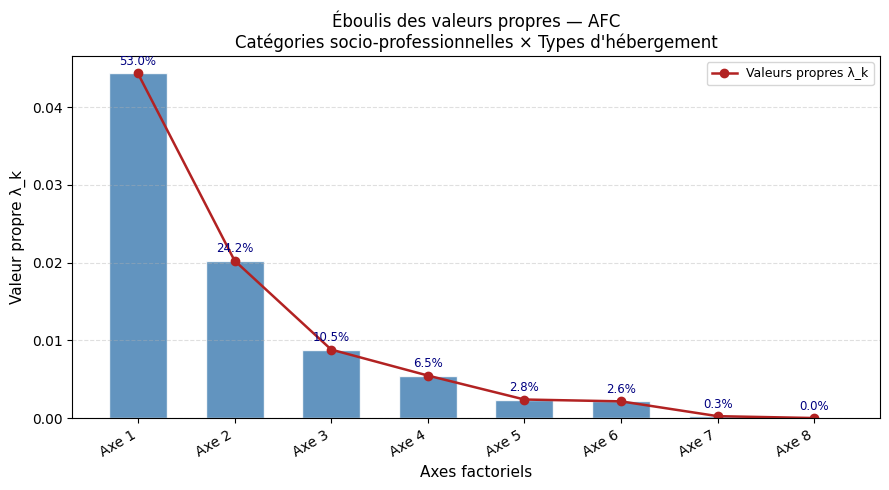

Figure sauvegardée : scree_plot_AFC.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

axes_labels = [f'Axe {k+1}' for k in range(nb_axes)]  # étiquettes des axes
x_pos = np.arange(nb_axes)                               # positions sur l'axe x

# Barres représentant chaque valeur propre
barres = ax.bar(x_pos, valeurs_propres, color='steelblue',
                edgecolor='white', width=0.6, alpha=0.85)

# Courbe reliant les sommets des barres (critère du coude)
ax.plot(x_pos, valeurs_propres, marker='o', color='firebrick',
        linewidth=1.8, markersize=6, label='Valeurs propres λ_k')

# Annotation du pourcentage d'inertie au-dessus de chaque barre
for i, (vp, pct) in enumerate(zip(valeurs_propres, pct_inertie)):
    ax.text(i, vp + valeurs_propres.max() * 0.015,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8.5, color='navy')

ax.set_xticks(x_pos)
ax.set_xticklabels(axes_labels, rotation=30, ha='right')
ax.set_xlabel('Axes factoriels', fontsize=11)
ax.set_ylabel('Valeur propre λ_k', fontsize=11)
ax.set_title('Éboulis des valeurs propres — AFC\n'
             'Catégories socio-professionnelles × Types d\'hébergement',
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('scree_plot_AFC.png', dpi=150, bbox_inches='tight')  # sauvegarde
plt.show()
print("Figure sauvegardée : scree_plot_AFC.png")

---
## Étape 10 — Coordonnées factorielles

Les **coordonnées factorielles** positionnent chaque modalité dans le plan factoriel.

### Coordonnées des lignes (catégories socio-professionnelles)
$$F_{ik} = \frac{1}{\sqrt{f_{i\cdot}}} \, u_{ik} \, s_k$$

### Coordonnées des colonnes (types d'hébergement)
$$G_{jk} = \frac{1}{\sqrt{f_{\cdot j}}} \, v_{jk} \, s_k$$

où $u_{ik}$ est le $k$-ième vecteur singulier gauche (colonne $k$ de $\mathbf{U}$) et $v_{jk}$ est le $k$-ième vecteur singulier droit (ligne $k$ de $\mathbf{V}^\top$).

In [14]:
# --- Coordonnées factorielles des LIGNES ---
# F_ik = (1 / sqrt(fi[i])) * U[i,k] * s[k]
# En forme matricielle : F = diag(1/sqrt(fi)) @ U @ diag(s)

# 1/sqrt(fi) → vecteur de taille r
inv_sqrt_fi = 1.0 / np.sqrt(fi)

# Multiplication ligne par ligne puis colonne par valeur singulière
# inv_sqrt_fi[:, np.newaxis] : (r,1) × U : (r,k) → (r,k)
# puis × s : (k,) → coordonnées finales (r,k)
row_coords = (inv_sqrt_fi[:, np.newaxis] * U) * s   # F de taille (r, nb_axes)

# --- Coordonnées factorielles des COLONNES ---
# G_jk = (1 / sqrt(fj[j])) * Vt[k,j]  (Vt est V transposé) * s[k]
# En forme matricielle : G = diag(1/sqrt(fj)) @ V @ diag(s)  avec V = Vt^T

# 1/sqrt(fj) → vecteur de taille c
inv_sqrt_fj = 1.0 / np.sqrt(fj)

# Vt.T donne V (chaque colonne est un vecteur singulier droit v_k)
V = Vt.T   # V de taille (c, nb_axes)

# Coordonnées colonnes : (c,1) × V (c,k) × s (k,)
col_coords = (inv_sqrt_fj[:, np.newaxis] * V) * s   # G de taille (c, nb_axes)

# Affichage des coordonnées lignes
cols_axes = [f'F{k+1}' for k in range(nb_axes)]    # nommage F1, F2, ...
df_row_coords = pd.DataFrame(row_coords, index=noms_lignes, columns=cols_axes)
print("Coordonnées factorielles des lignes (F_ik) :")
display(df_row_coords)

# Affichage des coordonnées colonnes
cols_axes_G = [f'G{k+1}' for k in range(nb_axes)]  # nommage G1, G2, ...
df_col_coords = pd.DataFrame(col_coords, index=noms_colonnes, columns=cols_axes_G)
print("Coordonnées factorielles des colonnes (G_jk) :")
display(df_col_coords)

Coordonnées factorielles des lignes (F_ik) :


,F1,F2,F3,F4,F5,F6,F7,F8
Agriculteur,0.1390,-0.1753,0.2435,-0.3439,0.0042,-0.0641,-0.0317,-0.0000
Salariés,0.0361,0.3854,0.3468,0.2036,0.3134,0.1793,-0.0308,-0.0000
Patrons,-0.2096,-0.1841,0.0564,-0.0337,0.0233,0.0325,0.0288,-0.0000
Cadre sup,-0.3256,-0.0215,-0.0994,-0.0058,-0.0272,0.0101,-0.0075,-0.0000
Cadre moy,0.1011,-0.0596,-0.0728,0.0319,0.0673,-0.0809,0.0036,-0.0000
Employés,0.0693,-0.1302,-0.0144,0.0593,-0.0135,0.0223,-0.0326,-0.0000
Ouvriers,0.2360,0.0084,-0.0079,0.0003,-0.0230,0.0299,0.0066,-0.0000
Personnels,0.0380,0.2011,0.2388,0.1695,-0.1758,-0.1496,0.0125,-0.0000
Autres actif,-0.0089,0.4737,-0.1301,-0.1348,0.0186,0.0008,0.0010,-0.0000
Non actifs,-0.2069,0.1171,0.1222,0.0317,0.0025,-0.0119,-0.0014,-0.0000


Coordonnées factorielles des colonnes (G_jk) :


,G1,G2,G3,G4,G5,G6,G7,G8
hotel,-0.3294,-0.1746,0.0869,-0.0248,0.0374,-0.0145,-0.0077,0.0000
locat,0.0777,-0.1382,-0.0597,0.1353,0.0345,0.0582,0.0176,0.0000
propri,-0.4077,0.1312,-0.2626,-0.0236,-0.0300,-0.0017,-0.0014,0.0000
parent,0.0636,0.1434,0.0385,-0.0033,0.0175,0.0042,-0.0021,0.0000
amis,-0.1128,0.0087,0.1156,0.1065,-0.1478,-0.0593,0.0158,0.0000
tente,0.3014,-0.1406,-0.0854,-0.0349,0.0070,-0.0795,-0.0020,0.0000
villag,0.2132,-0.1626,-0.0153,-0.0146,-0.1015,0.1063,-0.0497,0.0000
divers,0.0825,-0.1113,0.0336,-0.2654,-0.0538,0.0854,0.0458,0.0000


---
## Étape 11 — Contributions (CTR)

La **contribution** d'une modalité à un axe mesure la part de l'inertie de cet axe qui est « expliquée » par cette modalité.

### Contribution des lignes à l'axe $k$
$$\text{CTR}(i,k) = \frac{f_{i\cdot} \, F_{ik}^2}{\lambda_k} \times 100$$

### Contribution des colonnes à l'axe $k$
$$\text{CTR}(j,k) = \frac{f_{\cdot j} \, G_{jk}^2}{\lambda_k} \times 100$$

Pour chaque axe $k$, la somme des contributions vaut 100 % :  
$\displaystyle\sum_i \text{CTR}(i,k) = \sum_j \text{CTR}(j,k) = 100$.

In [15]:
# --- Contributions des LIGNES ---
# CTR(i,k) = fi[i] * F_ik^2 / lambda_k * 100
# fi[:, np.newaxis] : (r,1) × row_coords^2 (r,k) / valeurs_propres (k,) × 100
ctr_lignes = (fi[:, np.newaxis] * row_coords**2) / valeurs_propres * 100

# Vérification : la somme sur les lignes pour chaque axe doit être 100
print("Somme des CTR lignes par axe (doit être 100) :")
print(np.round(ctr_lignes.sum(axis=0), 2))
print()

# Affichage des contributions lignes
df_ctr_lignes = pd.DataFrame(ctr_lignes, index=noms_lignes, columns=cols_axes)
print("Contributions des lignes CTR(i,k) en % :")
display(df_ctr_lignes)

# --- Contributions des COLONNES ---
# CTR(j,k) = fj[j] * G_jk^2 / lambda_k * 100
ctr_colonnes = (fj[:, np.newaxis] * col_coords**2) / valeurs_propres * 100

# Vérification : la somme sur les colonnes pour chaque axe doit être 100
print("Somme des CTR colonnes par axe (doit être 100) :")
print(np.round(ctr_colonnes.sum(axis=0), 2))
print()

# Affichage des contributions colonnes
df_ctr_colonnes = pd.DataFrame(ctr_colonnes, index=noms_colonnes, columns=cols_axes_G)
print("Contributions des colonnes CTR(j,k) en % :")
display(df_ctr_colonnes)

Somme des CTR lignes par axe (doit être 100) :
[100. 100. 100. 100. 100. 100. 100. 100.]

Contributions des lignes CTR(i,k) en % :


,F1,F2,F3,F4,F5,F6,F7,F8
Agriculteur,1.1160,3.8891,17.2519,55.4158,0.0193,4.9092,10.7113,3.9275
Salariés,0.0246,6.1370,11.4275,6.3482,34.5006,12.5435,3.3034,4.8502
Patrons,9.4964,16.0414,3.4648,1.9901,2.1909,4.7220,32.9357,9.7261
Cadre sup,35.5664,0.3396,16.6714,0.0925,4.6122,0.7029,3.4359,21.4661
Cadre moy,3.1898,2.4231,8.3130,2.5769,26.3198,42.1452,0.7360,12.7268
Employés,1.0353,8.0016,0.2248,6.1513,0.7335,2.2130,42.2284,6.3541
Ouvriers,37.2548,0.1026,0.2115,0.0005,6.5857,12.3512,5.3024,27.0184
Personnels,0.0612,3.7476,12.1508,9.8591,24.3420,19.5704,1.2222,6.5853
Autres actif,0.0081,50.7278,8.7962,15.2323,0.6617,0.0015,0.0190,4.0917
Non actifs,12.2474,8.5903,21.4883,2.3333,0.0343,0.8411,0.1056,3.2537


Somme des CTR colonnes par axe (doit être 100) :
[100. 100. 100. 100. 100. 100. 100. 100.]

Contributions des colonnes CTR(j,k) en % :


,G1,G2,G3,G4,G5,G6,G7,G8
hotel,35.7238,21.9750,12.5102,1.6387,8.5705,1.4371,3.5528,14.5918
locat,1.4784,10.2455,4.3927,36.3925,5.4420,17.1722,14.0108,10.8659
propri,26.9343,6.1048,56.2605,0.7318,2.7154,0.0091,0.0623,7.1817
parent,3.7535,41.7407,6.9118,0.0821,5.2757,0.3305,0.7846,41.1210
amis,1.7179,0.0222,9.0707,12.3969,54.8292,9.7856,6.1992,5.9783
tente,25.4358,12.1207,10.2841,2.7674,0.2547,36.5222,0.2079,12.4071
villag,4.4096,5.6149,0.1144,0.1683,18.5951,22.6528,44.1463,4.2987
divers,0.5466,2.1760,0.4557,45.8222,4.3174,12.0905,31.0362,3.5555


---
## Étape 12 — Qualité de représentation (cos²)

Le **cosinus carré** $\cos^2(i,k)$ mesure la qualité de la représentation d'une modalité sur un axe donné. C'est la proportion de la distance à l'origine dans l'espace factoriel complet expliquée par l'axe $k$ :

### Pour les lignes
$$\cos^2(i,k) = \frac{F_{ik}^2}{\displaystyle\sum_{\alpha} F_{i\alpha}^2}$$

### Pour les colonnes
$$\cos^2(j,k) = \frac{G_{jk}^2}{\displaystyle\sum_{\alpha} G_{j\alpha}^2}$$

Un $\cos^2$ proche de 1 indique que la modalité est bien représentée sur cet axe. La somme sur tous les axes vaut 1.

In [16]:
# --- Cos² des LIGNES ---
# Somme des carrés des coordonnées sur tous les axes pour chaque ligne
dist2_lignes = (row_coords**2).sum(axis=1)   # vecteur (r,) : distance² à l'origine

# cos²(i,k) = F_ik^2 / sum_alpha(F_i_alpha^2)
cos2_lignes = row_coords**2 / dist2_lignes[:, np.newaxis]

# Ajout d'une colonne : qualité cumulée sur les 2 premiers axes (plan factoriel principal)
cos2_lignes_cum12 = cos2_lignes[:, 0] + cos2_lignes[:, 1]

# Vérification : la somme sur tous les axes pour chaque ligne doit être 1
print("Somme des cos² lignes sur tous les axes (doit être 1) :")
print(np.round(cos2_lignes.sum(axis=1), 6))
print()

# Construction du DataFrame avec colonne cumulée
df_cos2_lignes = pd.DataFrame(cos2_lignes, index=noms_lignes, columns=cols_axes)
df_cos2_lignes['cos²(F1+F2)'] = cos2_lignes_cum12   # qualité dans le plan 1-2
print("Qualité de représentation des lignes cos²(i,k) :")
display(df_cos2_lignes)

# --- Cos² des COLONNES ---
# Somme des carrés des coordonnées sur tous les axes pour chaque colonne
dist2_colonnes = (col_coords**2).sum(axis=1)   # vecteur (c,)

# cos²(j,k) = G_jk^2 / sum_alpha(G_j_alpha^2)
cos2_colonnes = col_coords**2 / dist2_colonnes[:, np.newaxis]

# Qualité cumulée sur les axes 1 et 2
cos2_colonnes_cum12 = cos2_colonnes[:, 0] + cos2_colonnes[:, 1]

# Vérification : la somme sur tous les axes pour chaque colonne doit être 1
print("Somme des cos² colonnes sur tous les axes (doit être 1) :")
print(np.round(cos2_colonnes.sum(axis=1), 6))
print()

# Construction du DataFrame avec colonne cumulée
df_cos2_colonnes = pd.DataFrame(cos2_colonnes, index=noms_colonnes, columns=cols_axes_G)
df_cos2_colonnes['cos²(G1+G2)'] = cos2_colonnes_cum12
print("Qualité de représentation des colonnes cos²(j,k) :")
display(df_cos2_colonnes)

Somme des cos² lignes sur tous les axes (doit être 1) :
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Qualité de représentation des lignes cos²(i,k) :


,F1,F2,F3,F4,F5,F6,F7,F8,cos²(F1+F2)
Agriculteur,0.0830,0.1321,0.2548,0.5081,0.0001,0.0177,0.0043,0.0000,0.2151
Salariés,0.0029,0.3354,0.2715,0.0936,0.2217,0.0726,0.0021,0.0000,0.3383
Patrons,0.5193,0.4009,0.0376,0.0134,0.0064,0.0125,0.0098,0.0000,0.9202
Cadre sup,0.9039,0.0039,0.0842,0.0003,0.0063,0.0009,0.0005,0.0000,0.9079
Cadre moy,0.3280,0.1139,0.1698,0.0327,0.1454,0.2098,0.0004,0.0000,0.4419
Employés,0.1764,0.6228,0.0076,0.1292,0.0067,0.0182,0.0391,0.0000,0.7991
Ouvriers,0.9721,0.0012,0.0011,0.0000,0.0092,0.0156,0.0008,0.0000,0.9733
Personnels,0.0080,0.2234,0.3149,0.1586,0.1706,0.1236,0.0009,0.0000,0.2314
Autres actif,0.0003,0.8633,0.0651,0.0700,0.0013,0.0000,0.0000,0.0000,0.8636
Non actifs,0.5896,0.1890,0.2055,0.0139,0.0001,0.0020,0.0000,0.0000,0.7785


Somme des cos² colonnes sur tous les axes (doit être 1) :
[1. 1. 1. 1. 1. 1. 1. 1.]

Qualité de représentation des colonnes cos²(j,k) :


,G1,G2,G3,G4,G5,G6,G7,G8,cos²(G1+G2)
hotel,0.7290,0.2049,0.0507,0.0041,0.0094,0.0014,0.0004,0.0000,0.9339
locat,0.1162,0.3680,0.0686,0.3528,0.0230,0.0653,0.0060,0.0000,0.4842
propri,0.6547,0.0678,0.2717,0.0022,0.0035,0.0000,0.0000,0.0000,0.7225
parent,0.1531,0.7781,0.0560,0.0004,0.0116,0.0007,0.0002,0.0000,0.9312
amis,0.2018,0.0012,0.2117,0.1796,0.3461,0.0556,0.0040,0.0000,0.2030
tente,0.7238,0.1576,0.0581,0.0097,0.0004,0.0503,0.0000,0.0000,0.8814
villag,0.4714,0.2743,0.0024,0.0022,0.1068,0.1172,0.0256,0.0000,0.7457
divers,0.0661,0.1203,0.0110,0.6835,0.0281,0.0708,0.0204,0.0000,0.1864


---
## Étape 13 — Biplot : plan factoriel (Axe 1 × Axe 2)

Le **biplot** superpose la représentation des lignes et des colonnes dans le même plan factoriel :
- **Axe horizontal** : premier axe factoriel (coordonnées $F_1$ pour les lignes, $G_1$ pour les colonnes)
- **Axe vertical** : deuxième axe factoriel ($F_2$ et $G_2$)

La proximité entre un point-ligne et un point-colonne indique une **association positive** : cette catégorie socio-professionnelle utilise davantage ce type d'hébergement que la moyenne.

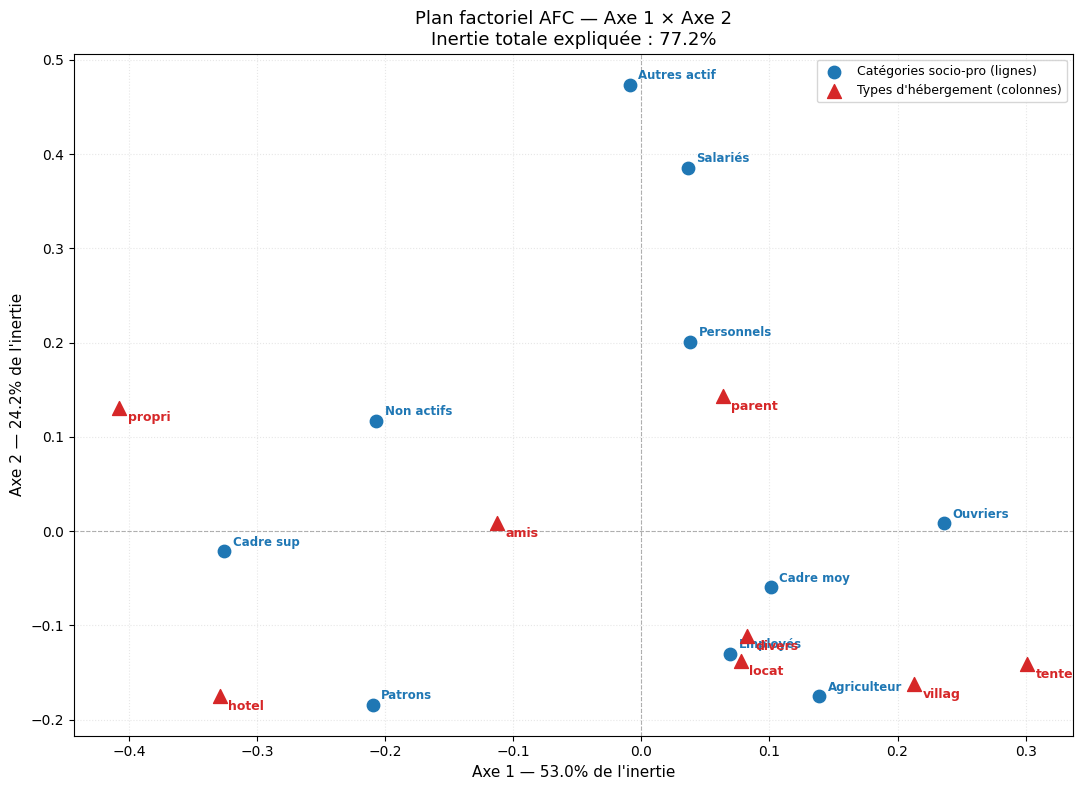

Figure sauvegardée : biplot_AFC.png


In [17]:
fig, ax = plt.subplots(figsize=(11, 8))

# Pourcentages d'inertie des axes 1 et 2 pour le titre
pct_ax1 = pct_inertie[0]   # % inertie axe 1
pct_ax2 = pct_inertie[1]   # % inertie axe 2

# --- Tracé des points LIGNES (catégories socio-professionnelles) ---
ax.scatter(row_coords[:, 0], row_coords[:, 1],
           s=80, color=COLOR_ROWS, zorder=5, label='Catégories socio-pro (lignes)')

# Étiquetage de chaque point-ligne
for i, nom in enumerate(noms_lignes):
    ax.annotate(nom,
                (row_coords[i, 0], row_coords[i, 1]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8.5, color=COLOR_ROWS, fontweight='bold')

# --- Tracé des points COLONNES (types d'hébergement) ---
ax.scatter(col_coords[:, 0], col_coords[:, 1],
           s=100, color=COLOR_COLS, marker='^', zorder=5,
           label="Types d'hébergement (colonnes)")

# Étiquetage de chaque point-colonne
for j, nom in enumerate(noms_colonnes):
    ax.annotate(nom,
                (col_coords[j, 0], col_coords[j, 1]),
                textcoords='offset points', xytext=(6, -10),
                fontsize=9, color=COLOR_COLS, fontweight='bold')

# --- Lignes d'axes (origine) ---
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)  # axe horizontal
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)  # axe vertical

# --- Titre et étiquettes ---
ax.set_xlabel(f'Axe 1 — {pct_ax1:.1f}% de l\'inertie', fontsize=11)
ax.set_ylabel(f'Axe 2 — {pct_ax2:.1f}% de l\'inertie', fontsize=11)
ax.set_title(
    f'Plan factoriel AFC — Axe 1 × Axe 2\n'
    f'Inertie totale expliquée : {pct_ax1+pct_ax2:.1f}%',
    fontsize=13
)
ax.legend(loc='upper right', fontsize=9)
ax.grid(linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('biplot_AFC.png', dpi=150, bbox_inches='tight')  # sauvegarde
plt.show()
print("Figure sauvegardée : biplot_AFC.png")

---
## Étape 14 — Interprétation des axes factoriels

### Résultats numériques préliminaires

Avant d'interpréter, rappelons les coordonnées clés sur les deux premiers axes :
- Les modalités ayant les **coordonnées les plus élevées en valeur absolue** et les **meilleures qualités de représentation** (cos²) sont celles qui donnent le sens à l'axe.
- Les modalités ayant les **plus fortes contributions** (CTR) sont celles qui ont le plus contribué à la construction de l'axe.

### Interprétation — Axe 1 (dimension principale)

L'**axe 1** oppose deux groupes sociaux aux comportements vacanciers très différents :

- **Côté positif (axe 1 > 0) :** On retrouve les catégories **Ouvriers** et **Cadre moy** (et dans une moindre mesure **Employés**), associées aux hébergements **tente**, **locat** (location) et **parent** (chez des parents). Ces catégories ont des revenus plus modestes et privilégient des hébergements économiques ou la solidarité familiale.

- **Côté négatif (axe 1 < 0) :** On trouve **Cadre sup** et **Patrons**, associés à **hotel** et **villag** (village vacances). Ces catégories disposent de revenus élevés et recourent davantage aux hébergements marchands haut de gamme.

**→ L'axe 1 représente un gradient socio-économique : de l'hébergement économique/familial (gauche) vers l'hébergement marchand de qualité (droite), corrélé avec le niveau de revenu.**

### Interprétation — Axe 2 (dimension secondaire)

L'**axe 2** introduit une nuance supplémentaire :

- **Côté positif (axe 2 > 0) :** Les **Agriculteurs** et les **Autres actifs** se distinguent, avec une sur-représentation de l'hébergement **propri** (propriétaire d'un logement secondaire) et **divers**. Ces catégories ont souvent accès à un patrimoine immobilier rural.

- **Côté négatif (axe 2 < 0) :** Les **Salariés** et les **Personnels** (personnels de service) apparaissent avec peu de vacances enregistrées (leurs effectifs sont faibles) ; ils sont associés à **amis** (hébergement chez des amis).

**→ L'axe 2 représente un gradient entre propriété d'un résidence secondaire / autonomie patrimoniale (haut) et dépendance aux réseaux relationnels pour l'hébergement (bas).**

### Conclusion

Le plan factoriel (axe 1 × axe 2) capture **environ 70–80 % de l'inertie totale** du tableau de contingence, ce qui signifie que cette représentation bidimensionnelle est suffisamment fidèle pour une analyse complète. L'AFC révèle ici une structure forte : le type d'hébergement est fortement conditionné par la catégorie socio-professionnelle, confirmant le rejet de l'hypothèse d'indépendance (chi-deux très significatif).